In [8]:
import importnb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

print('OK')

OK


In [9]:
with importnb.Notebook():
    import acquisition_and_profiling as phase_1

#Load the dataset
df_train = pd.read_csv(
    filepath_or_buffer= phase_1.os.path.join(phase_1.trainning_data_path, f"train_{phase_1.subset}.txt") ,
    sep=r'\s+',
    names=phase_1.columns,
    index_col=False
)

#Set Engine_id and Cycle as a composite PK
df_train.set_index(['Engine_ID', 'Cycle'], inplace=True)

print('Shape   :', df_train.shape)
print('Columns :', df_train.columns.tolist())
print('Index   :', df_train.index.names)
print()
df_train.head(3)

Shape   : (20631, 24)
Columns : ['Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3', 'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21']
Index   : ['Engine_ID', 'Cycle']



Op_Setting_1  Op_Setting_2  Op_Setting_3  Sensor_1  Sensor_2  \
Engine_ID Cycle                                                                 
1         1           -0.0007       -0.0004         100.0    518.67    641.82   
          2            0.0019       -0.0003         100.0    518.67    642.15   
          3           -0.0043        0.0003         100.0    518.67    642.35   

                 Sensor_3  Sensor_4  Sensor_5  Sensor_6  Sensor_7  ...  \
Engine_ID Cycle                                                    ...   
1         1       1589.70   1400.60     14.62     21.61    554.36  ...   
          2       1591.82   1403.14     14.62     21.61    553.75  ...   
          3       1587.99   1404.20     14.62     21.61    554.26  ...   

                 Sensor_12  Sensor_13  Sensor_14  Sensor_15  Sensor_16  \
Engine_ID Cycle                                                          
1         1         521.66    2388.02    8138.62     8.4195       0.03   
          2         522.28    2388.07    8131.49     8.4318       0.03   
          3         522.42    2388.03    8133.23     8.4178       0.03   

                 Sensor_17  Sensor_18  Sensor_19  Sensor_20  Sensor_21  
Engine_ID Cycle                                                         
1         1            392       2388      100.0      39.06    23.4190  
          2            392       2388      100.0      39.00    23.4236  
          3            390       2388      100.0      38.95    23.3442  

[3 rows x 24 columns]

In [ ]:
sensor_cols = [c for c in df_train.columns if c not in ['Engine_ID', 'Cycle', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3']]

stats = df_train[sensor_cols].agg(['mean', 'std', 'min', 'max']).T.round(4)
stats['is_constant'] = stats['std'] < 0.01

print(f'Total features  : {len(df_train.columns)}')
print(f'Sensor columns  : {len(sensor_cols)}')
print(f'Total rows      : {len(df_train)}')
print(f'Engines         : {df_train.index.get_level_values("Engine_ID").nunique()}')
print()
print('Per-sensor stats:')
print(stats.to_string())

Total features  : 24
Sensor columns  : 21
Total rows      : 20631
Engines         : 100

Per-sensor stats:
                mean      std        min        max  is_constant
Sensor_1    518.6700   0.0000   518.6700   518.6700         True
Sensor_2    642.6809   0.5001   641.2100   644.5300        False
Sensor_3   1590.5231   6.1311  1571.0400  1616.9100        False
Sensor_4   1408.9338   9.0006  1382.2500  1441.4900        False
Sensor_5     14.6200   0.0000    14.6200    14.6200         True
Sensor_6     21.6098   0.0014    21.6000    21.6100         True
Sensor_7    553.3677   0.8851   549.8500   556.0600        False
Sensor_8   2388.0967   0.0710  2387.9000  2388.5600        False
Sensor_9   9065.2429  22.0829  9021.7300  9244.5900        False
Sensor_10     1.3000   0.0000     1.3000     1.3000         True
Sensor_11    47.5412   0.2671    46.8500    48.5300        False
Sensor_12   521.4135   0.7376   518.6900   523.3800        False
Sensor_13  2388.0962   0.0719  2387.8800  2388.5

In [13]:
# Identify constant sensors from the stats we just printed
constant_sensors = stats[stats['is_constant']].index.tolist()
useful_sensors   = [s for s in sensor_cols if s not in constant_sensors]

print('Dropped (constant) :', constant_sensors)
print('Remaining sensors  :', useful_sensors)
print(f'\n{len(sensor_cols)} sensors -> {len(useful_sensors)} useful sensors')

# Drop them from the DataFrame
df_train_ = df_train.drop(columns=constant_sensors)

print('\nNew shape:', df_train_.shape)

Dropped (constant) : ['Sensor_1', 'Sensor_5', 'Sensor_6', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']
Remaining sensors  : ['Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']

21 sensors -> 14 useful sensors

New shape: (20631, 17)


In [ ]:
# Calculate Maximum Lifespan (EOL) per Engine

engine_lifespans = df_train.groupby(level='Engine_ID').size()
engine_lifespans

# Extracting RUL

#Map The engine life span to the each Engine_ID
max_cycles_per_row = df_train.index.get_level_values('Engine_ID').map(engine_lifespans)
# max_cycles_per_row

#Calculate and add RUL
df_train['RUL'] = max_cycles_per_row - df_train.index.get_level_values('Cycle')
df_train

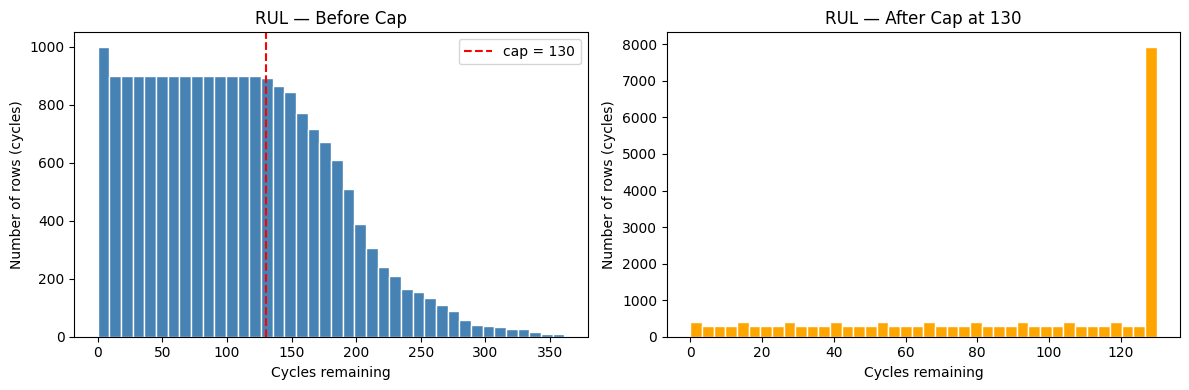

Max RUL after cap : 130
Min RUL           : 0


In [18]:
RUL_CAP = 130

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['RUL'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('RUL — Before Cap')
axes[0].set_xlabel('Cycles remaining')
axes[0].set_ylabel('Number of rows (cycles)')
axes[0].axvline(RUL_CAP, color='red', linestyle='--', label=f'cap = {RUL_CAP}')
axes[0].legend()

df_train_['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

axes[1].hist(df_train_['RUL'], bins=40, color='orange', edgecolor='white')
axes[1].set_title(f'RUL — After Cap at {RUL_CAP}')
axes[1].set_xlabel('Cycles remaining')
axes[1].set_ylabel('Number of rows (cycles)')

plt.tight_layout()
plt.show()

print(f'Max RUL after cap : {df_train_["RUL"].max()}')
print(f'Min RUL           : {df_train_["RUL"].min()}')

In [21]:
LAG_STEPS = [1, 2, 3]

for lag in LAG_STEPS:
    for col in useful_sensors:
        df_train[f'{col}_lag{lag}'] = (
            df_train.groupby(level='Engine_ID')[col]
            .shift(lag)
        )

lag_cols = [c for c in df_train.columns if '_lag' in c]

print(f'Lag columns added : {len(lag_cols)}')
print(f'Total columns now : {len(df_train.columns)}')
print(f'NaN rows introduced: {df_train[lag_cols].isna().any(axis=1).sum()}')
print()
# Show what the lag looks like for one engine and one sensor
sample = df_train.xs(1, level='Engine_ID')[['Sensor_9', 'Sensor_9_lag1', 'Sensor_9_lag2', 'Sensor_9_lag3']].head(6)
print('Example — Engine 1, sensor Sensor_9 with lags:')
print(sample.to_string())

Lag columns added : 42
Total columns now : 67
NaN rows introduced: 300

Example — Engine 1, sensor Sensor_9 with lags:
       Sensor_9  Sensor_9_lag1  Sensor_9_lag2  Sensor_9_lag3
Cycle                                                       
1       9046.19            NaN            NaN            NaN
2       9044.07        9046.19            NaN            NaN
3       9052.94        9044.07        9046.19            NaN
4       9049.48        9052.94        9044.07        9046.19
5       9055.15        9049.48        9052.94        9044.07
6       9049.68        9055.15        9049.48        9052.94


In [23]:
WINDOW = 5

for col in useful_sensors:
    grouped = df_train.groupby(level='Engine_ID')[col]
    df_train[f'{col}_roll_mean'] = grouped.transform(
        lambda x: x.rolling(WINDOW).mean()
    )
    df_train[f'{col}_roll_std'] = grouped.transform(
        lambda x: x.rolling(WINDOW).std()
    )

roll_cols = [c for c in df_train.columns if '_roll_' in c]

print(f'Rolling columns added : {len(roll_cols)}')
print(f'Total columns now     : {len(df_train.columns)}')
print()
# Show what rolling looks like for one engine and one sensor
sample = df_train.xs(1, level='Engine_ID')[['Sensor_9', 'Sensor_9_roll_mean', 'Sensor_9_roll_std']].head(8)
print('Example — Engine 1, sensor Sensor_9 with rolling window=5:')
print(sample.to_string())

Rolling columns added : 28
Total columns now     : 95

Example — Engine 1, sensor Sensor_9 with rolling window=5:
       Sensor_9  Sensor_9_roll_mean  Sensor_9_roll_std
Cycle                                                 
1       9046.19                 NaN                NaN
2       9044.07                 NaN                NaN
3       9052.94                 NaN                NaN
4       9049.48                 NaN                NaN
5       9055.15            9049.566           4.587366
6       9049.68            9050.264           4.193904
7       9059.13            9053.276           4.038407
8       9040.80            9050.848           6.915502


In [24]:
rows_before = len(df_train)

df = df_train.dropna()

rows_after   = len(df)
rows_dropped = rows_before - rows_after
engines      = df.index.get_level_values('Engine_ID').nunique()

print(f'Rows before : {rows_before}')
print(f'Rows dropped: {rows_dropped}  ({rows_dropped / rows_before * 100:.1f}%)')
print(f'Rows after  : {rows_after}')
print(f'Engines kept: {engines}')
print(f'NaN remaining: {df.isna().sum().sum()}')
print()
print('Final feature set:')
feature_cols = [c for c in df.columns if c not in ['RUL', 'Label_30']]
print(f'  {len(feature_cols)} features')
print(f'  {len(df)} samples')

Rows before : 20631
Rows dropped: 400  (1.9%)
Rows after  : 20231
Engines kept: 100
NaN remaining: 0

Final feature set:
  94 features
  20231 samples


In [25]:
engine_ids  = df.index.get_level_values('Engine_ID').unique()
split_point = int(len(engine_ids) * 0.8)

train_engines = engine_ids[:split_point]
test_engines  = engine_ids[split_point:]

train_df = df.loc[df.index.get_level_values('Engine_ID').isin(train_engines)]
test_df  = df.loc[df.index.get_level_values('Engine_ID').isin(test_engines)]

feature_cols = [c for c in df.columns if c not in ['RUL', 'Label_30']]

X_train = train_df[feature_cols].values
y_train = train_df['RUL'].values

X_test  = test_df[feature_cols].values
y_test  = test_df['RUL'].values

print(f'Train engines : {len(train_engines)}  (engine {train_engines[0]} to {train_engines[-1]})')
print(f'Test engines  : {len(test_engines)}  (engine {test_engines[0]} to {test_engines[-1]})')
print()
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Train engines : 80  (engine 1 to 80)
Test engines  : 20  (engine 81 to 100)

X_train : (15818, 94)
X_test  : (4413, 94)
y_train : (15818,)
y_test  : (4413,)


In [26]:
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{label:<30} RMSE: {rmse:6.2f}   R²: {r2:.4f}')
    return rmse, r2

print('evaluate() ready.')

evaluate() ready.


In [27]:
rf_baseline = RandomForestRegressor(
    n_estimators = 100,
    max_features = 'sqrt',
    max_depth    = None,   # unlimited — will likely overfit
    random_state = 42,
    n_jobs       = -1
)

rf_baseline.fit(X_train, y_train)
print('Training complete.')
print()

evaluate(y_train, rf_baseline.predict(X_train), label='Baseline — Train')
evaluate(y_test,  rf_baseline.predict(X_test),  label='Baseline — Test')

Training complete.

Baseline — Train               RMSE:  13.04   R²: 0.9597
Baseline — Test                RMSE:  49.82   R²: 0.5762


(np.float64(49.82123074296905), 0.5762003655315098)

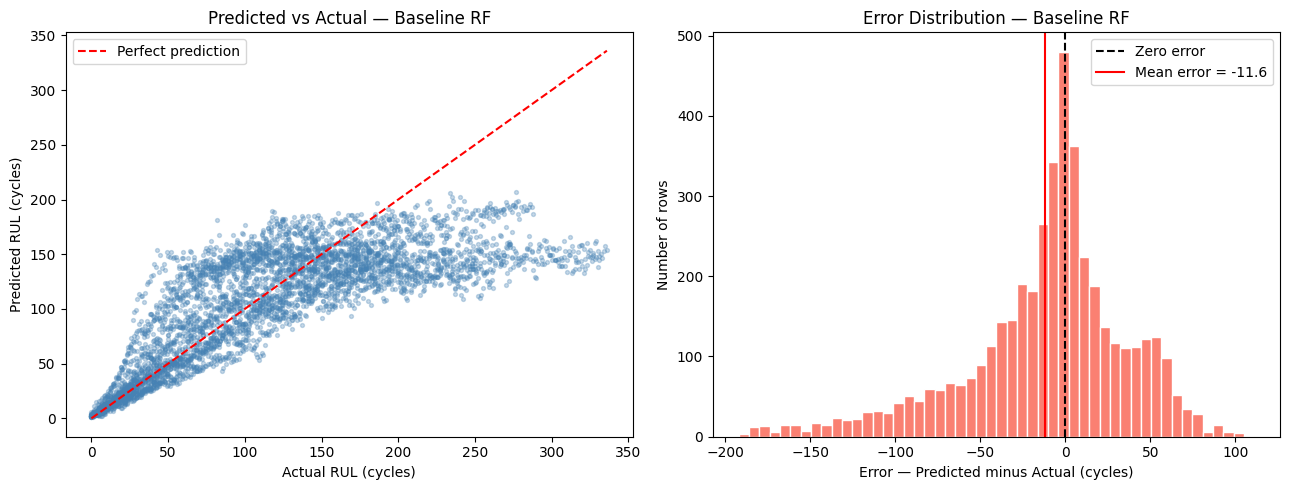

Mean error (bias) : -11.63 cycles
Std of errors     : 48.45 cycles

Positive mean -> model overestimates RUL (engine runs longer than expected)
Negative mean -> model underestimates RUL (engine pulled earlier than needed)


In [28]:
y_pred_baseline = rf_baseline.predict(X_test)
errors          = y_pred_baseline - y_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter: predicted vs actual ---
axes[0].scatter(y_test, y_pred_baseline, alpha=0.3, s=8, color='steelblue')
lim = max(y_test.max(), y_pred_baseline.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title('Predicted vs Actual — Baseline RF')
axes[0].legend()

# --- Error distribution ---
axes[1].hist(errors, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0,            color='black', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(errors.mean(), color='red',   linestyle='-',  linewidth=1.5, label=f'Mean error = {errors.mean():.1f}')
axes[1].set_xlabel('Error — Predicted minus Actual (cycles)')
axes[1].set_ylabel('Number of rows')
axes[1].set_title('Error Distribution — Baseline RF')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean error (bias) : {errors.mean():+.2f} cycles')
print(f'Std of errors     : {errors.std():.2f} cycles')
print()
print('Positive mean -> model overestimates RUL (engine runs longer than expected)')
print('Negative mean -> model underestimates RUL (engine pulled earlier than needed)')

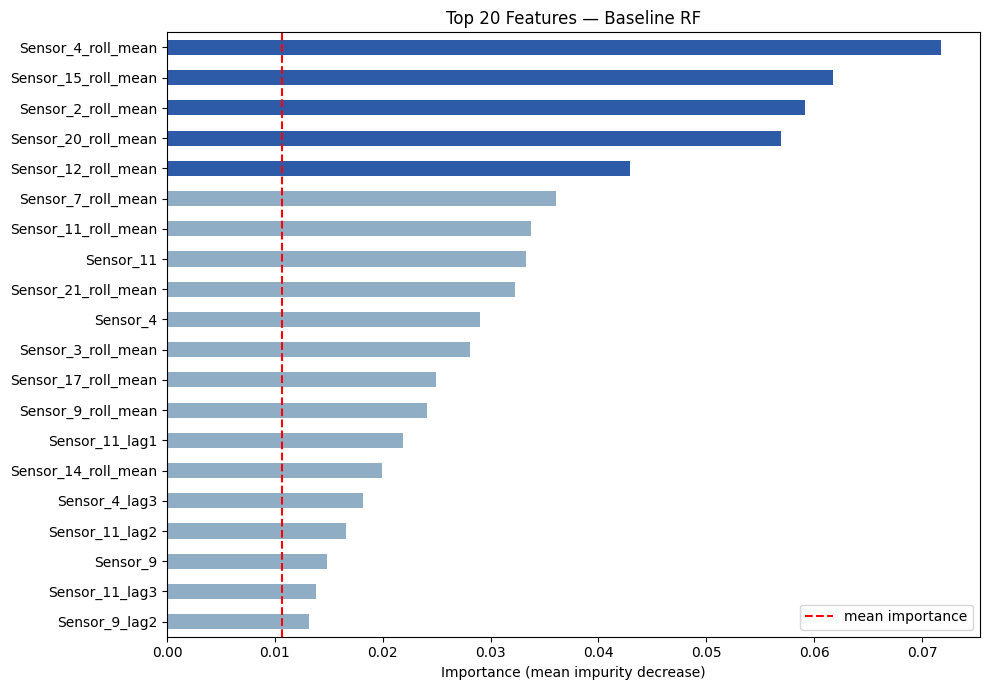

Top 10 features:
Sensor_4_roll_mean     0.071790
Sensor_15_roll_mean    0.061769
Sensor_2_roll_mean     0.059118
Sensor_20_roll_mean    0.056933
Sensor_12_roll_mean    0.042959
Sensor_7_roll_mean     0.036108
Sensor_11_roll_mean    0.033763
Sensor_11              0.033245
Sensor_21_roll_mean    0.032231
Sensor_4               0.029065

Bottom 5 features (least useful):
Sensor_16       0.0
Op_Setting_3    0.0
Sensor_1        0.0
Sensor_5        0.0
Sensor_10       0.0


In [29]:
feat_imp = pd.Series(
    rf_baseline.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_n = 20
top   = feat_imp.head(top_n).sort_values(ascending=True)

colors = ['#2E5BA8' if i >= top_n - 5 else '#90ADC6' for i in range(top_n)]

plt.figure(figsize=(10, 7))
top.plot(kind='barh', color=colors)
plt.axvline(feat_imp.mean(), color='red', linestyle='--', label='mean importance')
plt.title(f'Top {top_n} Features — Baseline RF')
plt.xlabel('Importance (mean impurity decrease)')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string())
print()
print('Bottom 5 features (least useful):')
print(feat_imp.tail(5).to_string())

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [6, 10, 14, 20],
    'max_features': ['sqrt'],
}

grid = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'neg_root_mean_squared_error',
    verbose    = 1,
    n_jobs     = -1
)

grid.fit(X_train, y_train)

print(f'\nBest parameters : {grid.best_params_}')
print(f'Best CV RMSE    : {-grid.best_score_:.2f} cycles')

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE    : 38.16 cycles


=== Baseline ===
Train                          RMSE:  13.04   R²: 0.9597
Test                           RMSE:  49.82   R²: 0.5762

=== Tuned (max_depth=10, n_estimators=200) ===
Train                          RMSE:  31.17   R²: 0.7693
Test                           RMSE:  49.74   R²: 0.5776



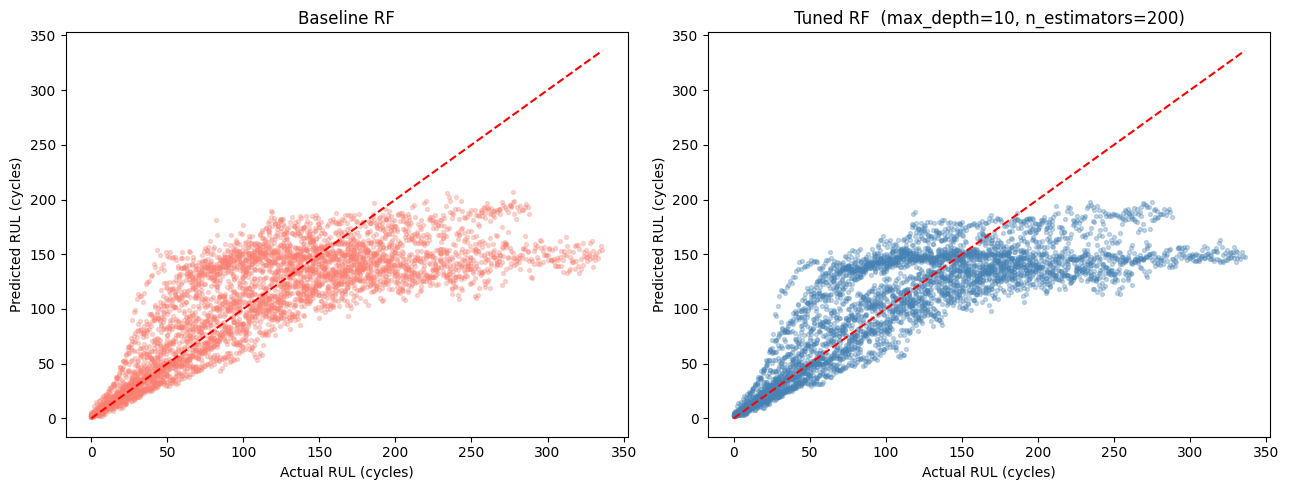

In [31]:
rf_tuned     = grid.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

print('=== Baseline ===')
evaluate(y_train, rf_baseline.predict(X_train), label='Train')
evaluate(y_test,  y_pred_baseline,               label='Test')

print()
print('=== Tuned (max_depth=10, n_estimators=200) ===')
evaluate(y_train, rf_tuned.predict(X_train), label='Train')
evaluate(y_test,  y_pred_tuned,               label='Test')

print()
# Side-by-side scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(y_test.max(), y_pred_tuned.max())

axes[0].scatter(y_test, y_pred_baseline, alpha=0.3, s=8, color='salmon')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_title('Baseline RF')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')

axes[1].scatter(y_test, y_pred_tuned, alpha=0.3, s=8, color='steelblue')
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[1].set_title('Tuned RF  (max_depth=10, n_estimators=200)')
axes[1].set_xlabel('Actual RUL (cycles)')
axes[1].set_ylabel('Predicted RUL (cycles)')

plt.tight_layout()
plt.show()

In [32]:
RF_BENCHMARK_RMSE, RF_BENCHMARK_R2 = evaluate(
    y_test, y_pred_tuned, label='RF Final Benchmark'
)

print()
print('=' * 45)
print('         RANDOM FOREST — FINAL SUMMARY')
print('=' * 45)
print(f'  Features         : {X_train.shape[1]}')
print(f'    - Original     : {len(useful_sensors)}')
print(f'    - Lag (t-1~3)  : {len(useful_sensors) * 3}')
print(f'    - Rolling (w=5): {len(useful_sensors) * 2}')
print(f'  Best max_depth   : {grid.best_params_["max_depth"]}')
print(f'  Best n_estimators: {grid.best_params_["n_estimators"]}')
print(f'  Train RMSE       : {np.sqrt(__import__("sklearn.metrics", fromlist=["mean_squared_error"]).mean_squared_error(y_train, rf_tuned.predict(X_train))):.2f}')
print(f'  Test  RMSE       : {RF_BENCHMARK_RMSE:.2f}  <-- CNN will beat this')
print(f'  Test  R²         : {RF_BENCHMARK_R2:.4f}')
print('=' * 45)
print()
print('RF_BENCHMARK_RMSE and RF_BENCHMARK_R2 are')
print('importable by the CNN notebook via importnb.')

RF Final Benchmark             RMSE:  49.74   R²: 0.5776

         RANDOM FOREST — FINAL SUMMARY
  Features         : 94
    - Original     : 14
    - Lag (t-1~3)  : 42
    - Rolling (w=5): 28
  Best max_depth   : 10
  Best n_estimators: 200
  Train RMSE       : 31.17
  Test  RMSE       : 49.74  <-- CNN will beat this
  Test  R²         : 0.5776

RF_BENCHMARK_RMSE and RF_BENCHMARK_R2 are
importable by the CNN notebook via importnb.


=== Uncapped test RUL (current) ===
Tuned RF                       RMSE:  49.74   R²: 0.5776

=== Capped test RUL (fair zone) ===
Tuned RF                       RMSE:  28.25   R²: 0.5729



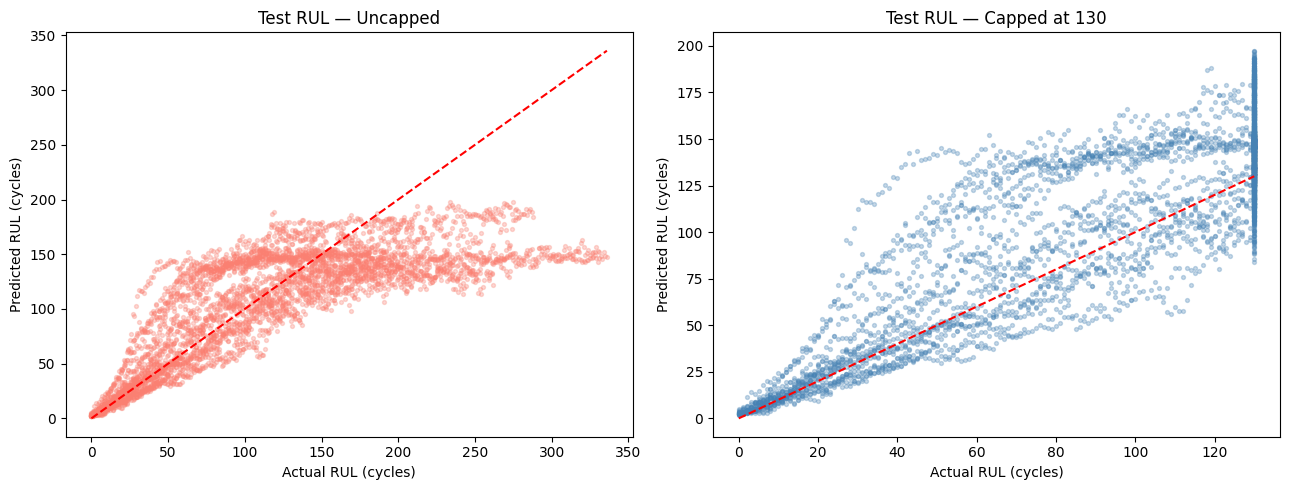

Rows where actual RUL > cap (affected rows): 1793
Total test rows                            : 4413


In [33]:
y_test_capped = y_test.clip(max=RUL_CAP)

print('=== Uncapped test RUL (current) ===')
evaluate(y_test,        y_pred_tuned, label='Tuned RF')

print()
print('=== Capped test RUL (fair zone) ===')
evaluate(y_test_capped, y_pred_tuned, label='Tuned RF')

print()
# Show the difference visually
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test,        y_pred_tuned, alpha=0.3, s=8, color='salmon')
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=1.5)
axes[0].set_title('Test RUL — Uncapped')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')

axes[1].scatter(y_test_capped, y_pred_tuned, alpha=0.3, s=8, color='steelblue')
axes[1].plot([0, RUL_CAP], [0, RUL_CAP], 'r--', linewidth=1.5)
axes[1].set_title(f'Test RUL — Capped at {RUL_CAP}')
axes[1].set_xlabel('Actual RUL (cycles)')
axes[1].set_ylabel('Predicted RUL (cycles)')

plt.tight_layout()
plt.show()

print('Rows where actual RUL > cap (affected rows):', (y_test > RUL_CAP).sum())
print('Total test rows                            :', len(y_test))